In [ ]:
!pip install tensorflow
import tensorflow as tf

In [71]:
# 🛠️ What you will create
    # A Neural Network model for classification using TensorFlow
    # Visualizations of data distribution and decision boundaries
    # Model performance evaluation on training and test sets
    # Experimentation with activation functions and optimizers


# 2. Set Up Your Python Environment and dataset
      # Ensure you have the required libraries installed:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers as Layers
from tensorflow.keras import models as models
import tensorflow as tf
from sklearn.datasets import make_circles

import scipy.io
import math
import sklearn
import sklearn.datasets

In [72]:
# dataset creation to work on:

from sklearn.datasets import make_circles
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X : ', X)
print('\n')
print('y : ', y)

X :  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]


y :  [1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1

In [73]:
# Définition du dataset
from sklearn.datasets import make_circles

samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X : ', X)
print('\n')
print('y : ', y)

X :  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]


y :  [1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1

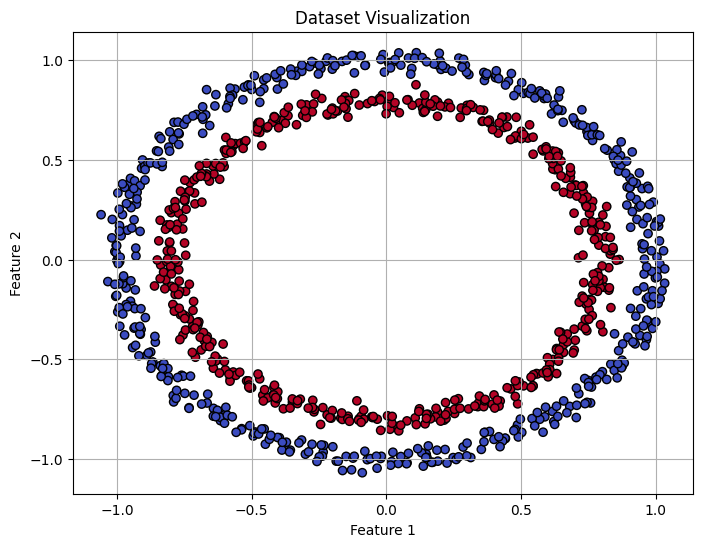

In [74]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Dataset Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [75]:
# Créer un modèle séquentiel
model = models.Sequential([
    Layers.Input(shape=(2,)),
    Layers.Dense(1, input_shape=(2,), activation='sigmoid')  # Une couche, activation sigmoid pour sortie binaire
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
# Compiler le modèle
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [77]:
# Entraîner le modèle
history = model.fit(X, y, epochs=20, verbose=2)
print('accuracy',history.history['accuracy'])


Epoch 1/20
32/32 - 1s - 17ms/step - accuracy: 0.4980 - loss: 0.8262
Epoch 2/20
32/32 - 0s - 4ms/step - accuracy: 0.4990 - loss: 0.8191
Epoch 3/20
32/32 - 0s - 3ms/step - accuracy: 0.4970 - loss: 0.8124
Epoch 4/20
32/32 - 0s - 4ms/step - accuracy: 0.4970 - loss: 0.8061
Epoch 5/20
32/32 - 0s - 3ms/step - accuracy: 0.4990 - loss: 0.7998
Epoch 6/20
32/32 - 0s - 4ms/step - accuracy: 0.5000 - loss: 0.7939
Epoch 7/20
32/32 - 0s - 4ms/step - accuracy: 0.4990 - loss: 0.7884
Epoch 8/20
32/32 - 0s - 3ms/step - accuracy: 0.5000 - loss: 0.7832
Epoch 9/20
32/32 - 0s - 4ms/step - accuracy: 0.5000 - loss: 0.7782
Epoch 10/20
32/32 - 0s - 4ms/step - accuracy: 0.4990 - loss: 0.7733
Epoch 11/20
32/32 - 0s - 3ms/step - accuracy: 0.4990 - loss: 0.7688
Epoch 12/20
32/32 - 0s - 5ms/step - accuracy: 0.4990 - loss: 0.7645
Epoch 13/20
32/32 - 0s - 3ms/step - accuracy: 0.4990 - loss: 0.7604
Epoch 14/20
32/32 - 0s - 3ms/step - accuracy: 0.4990 - loss: 0.7566
Epoch 15/20
32/32 - 0s - 3ms/step - accuracy: 0.4990 - l

In [78]:
# Improve the Model
    # Add more layers and neurons to the model.
    # Train the model for more epochs.
    # Try different optimizers like Adam instead of SGD.

model = models.Sequential([
    Layers.Dense(8, input_shape=(2,), activation='relu'),
    Layers.Dense(4, activation='relu'),
    Layers.Dense(1, activation='sigmoid')
])

In [79]:
# Compiler le modèle
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [80]:
# Entraîner le modèle
history = model.fit(X, y, epochs=100, verbose=2)
print('accuracy',history.history['accuracy'])

Epoch 1/100
32/32 - 1s - 44ms/step - accuracy: 0.4890 - loss: 0.7357
Epoch 2/100
32/32 - 0s - 4ms/step - accuracy: 0.4860 - loss: 0.7211
Epoch 3/100
32/32 - 0s - 4ms/step - accuracy: 0.4720 - loss: 0.7127
Epoch 4/100
32/32 - 0s - 5ms/step - accuracy: 0.4250 - loss: 0.7077
Epoch 5/100
32/32 - 0s - 5ms/step - accuracy: 0.4600 - loss: 0.7044
Epoch 6/100
32/32 - 0s - 4ms/step - accuracy: 0.4530 - loss: 0.7020
Epoch 7/100
32/32 - 0s - 4ms/step - accuracy: 0.4450 - loss: 0.7002
Epoch 8/100
32/32 - 0s - 3ms/step - accuracy: 0.4210 - loss: 0.6991
Epoch 9/100
32/32 - 0s - 5ms/step - accuracy: 0.4280 - loss: 0.6979
Epoch 10/100
32/32 - 0s - 5ms/step - accuracy: 0.4330 - loss: 0.6969
Epoch 11/100
32/32 - 0s - 4ms/step - accuracy: 0.4860 - loss: 0.6956
Epoch 12/100
32/32 - 0s - 3ms/step - accuracy: 0.5000 - loss: 0.6948
Epoch 13/100
32/32 - 0s - 3ms/step - accuracy: 0.5000 - loss: 0.6940
Epoch 14/100
32/32 - 0s - 4ms/step - accuracy: 0.5000 - loss: 0.6935
Epoch 15/100
32/32 - 0s - 5ms/step - accur

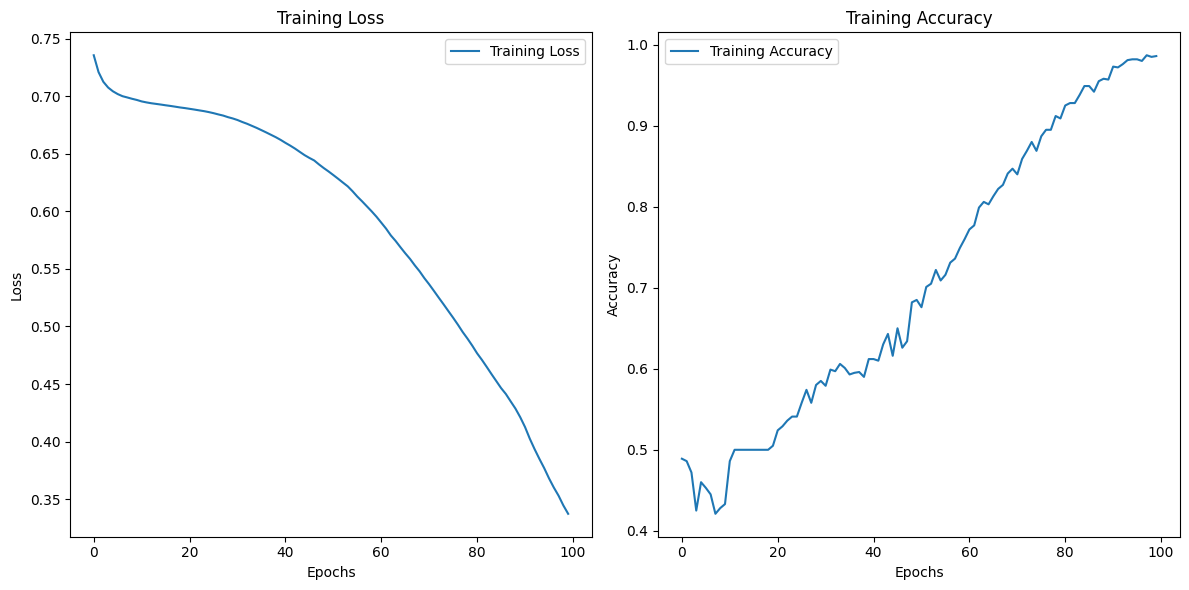

In [81]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()



In [82]:
# Visualize the Decision Boundary
    # Implement a function plot_decision_boundary() to visualize model predictions.
    # Plot decision boundaries for different models and compare results.

5266/5266 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


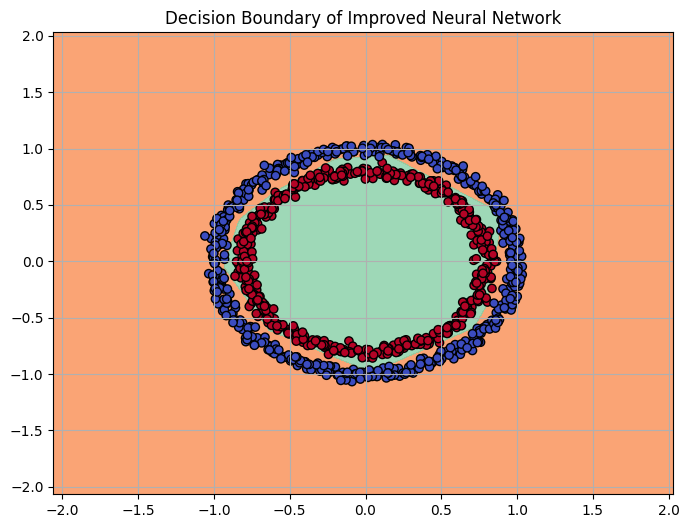

In [83]:
# Visualisation de la frontière de décision
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap="Spectral", alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors='k')
    plt.title("Decision Boundary of Improved Neural Network")
    plt.grid(True)
    plt.show()

plot_decision_boundary(model, X, y)

# Split Data into Training and Testing Sets
    # Use 80% data for training and 20% for testing.
    # Train the improved model on the training set.
    # Evaluate model performance on the test set.

In [84]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

In [85]:
# Split Data into Training and Testing Sets
    # Évaluer si le modèle est capable de généraliser sur des données qu’il n’a jamais vues.

# Séparation des données (80% entraînement, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=0)

In [86]:
# Evaluate and Visualize Final Model Performance
    # Check loss and accuracy on the test set.

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0707
Test accuracy: 1.00


Frontière sur train :
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


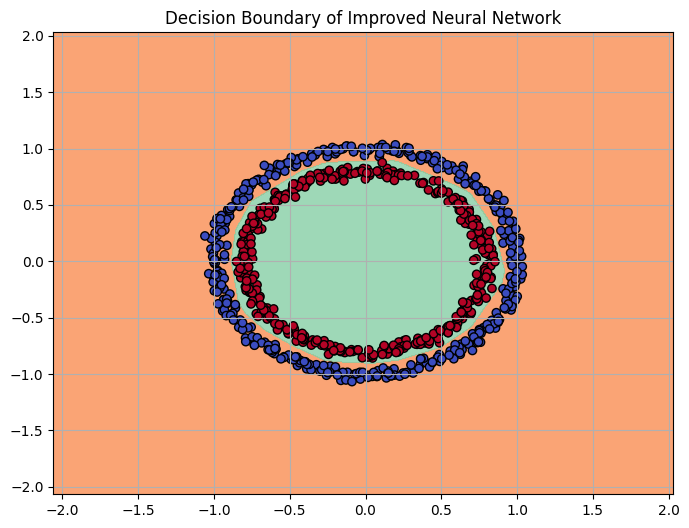

Frontière sur test :
5076/5076 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


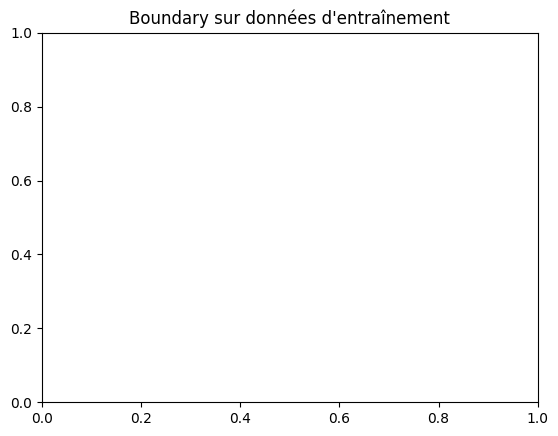

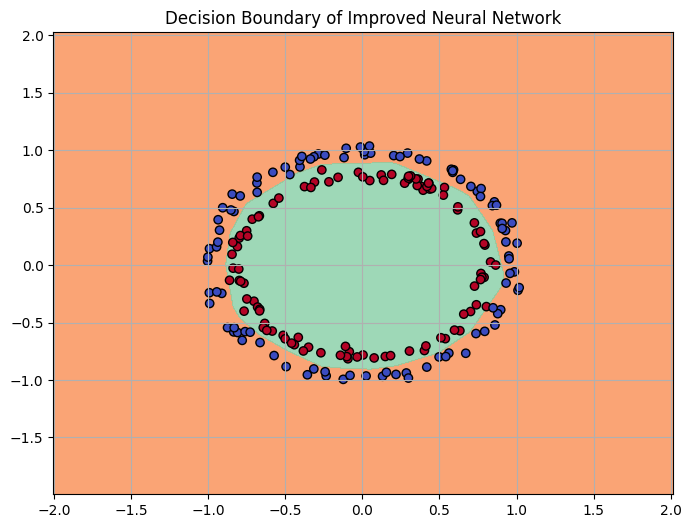

Text(0.5, 1.0, 'Boundary sur données de test')

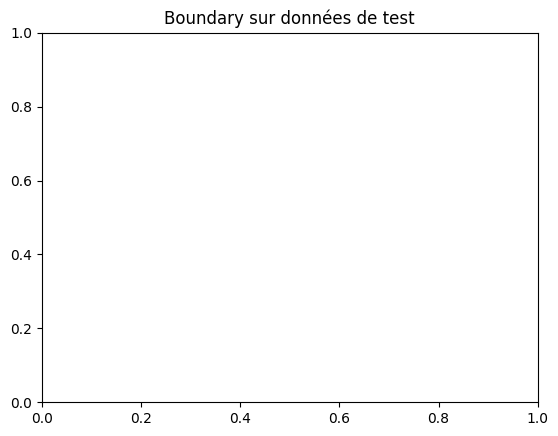

In [87]:
# Use plot_decision_boundary() to visualize predictions for both training and test data.
# Compare results and analyze improvements.

# Application de la fonction plot_decision_boundary() sur les deux ensembles :
print("Frontière sur train :")
plot_decision_boundary(model, X_train, y_train)
plt.title("Boundary sur données d'entraînement")
print("Frontière sur test :")
plot_decision_boundary(model, X_test, y_test)
plt.title("Boundary sur données de test")


In [88]:
# Évaluation sur l’ensemble de test
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f} - Loss: {loss:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0707 
Test Accuracy: 1.00 - Loss: 0.08


In [89]:
# Évaluer et Visualiser les performances finales du modèle + Résumer les enseignements
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [90]:
# Fonction pour visualiser les frontières de décision
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.01

# Création d'une grille de points (meshgrid)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

# Prédictions du modèle
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

# Affichage
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap="Spectral", alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors='k')
    plt.title(title)
    plt.grid(True)
    plt.show()

In [91]:
# Résumé synthétique
summary_text = f"""
Résumé des enseignements :

- Compris les différents types de classification : binaire, multi-classe, multi-label.
- Créé plusieurs modèles de réseaux de neurones pour classer des données simulées.
- Visualiser les frontières de décision permet de mieux interpréter les prédictions.
- Les fonctions d’activation comme `ReLU` accélèrent l’apprentissage.
- L’optimiseur `Adam` converge plus vite que `SGD`.
- Tuner les hyperparamètres (nœuds, couches, epochs) améliore les performances.

"""
print(summary_text)


Résumé des enseignements :

- Compris les différents types de classification : binaire, multi-classe, multi-label.
- Créé plusieurs modèles de réseaux de neurones pour classer des données simulées.
- Visualiser les frontières de décision permet de mieux interpréter les prédictions.
- Les fonctions d’activation comme `ReLU` accélèrent l’apprentissage.
- L’optimiseur `Adam` converge plus vite que `SGD`.
- Tuner les hyperparamètres (nœuds, couches, epochs) améliore les performances.




Classification with Neural Networks
Last Updated: February 20th, 2025

Daily Challenge: Classification with Neural Networks in TensorFlow


👩‍🏫 👩🏿‍🏫 What You’ll learn
Understand the different types of classification: Binary, Multi-class, and Multi-label
Learn how to build a Neural Network for Classification using TensorFlow
Improve model performance by adding layers, neurons, and using activation functions
Visualize decision boundaries to understand model predictions


🛠️ What you will create
A Neural Network model for classification using TensorFlow
Visualizations of data distribution and decision boundaries
Model performance evaluation on training and test sets
Experimentation with activation functions and optimizers


📖 Useful Resources
multiclass-classification-vs-multi-label-classification
getting-started-with-classification


What You Need to Do
1. Understand Classification Types

Read about Binary Classification, Multi-class Classification, and Multi-label Classification.
Write a brief explanation of each type with an example.


2. Set Up Your Python Environment and dataset

Ensure you have the required libraries installed:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles


It is time for creating a dataset to work on:

from sklearn.datasets import make_circles

samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X : ', X)
print('\n')
print('y : ', y)


Visualize the dataset using scatter plots to understand the data distribution.


3. Build a Basic Neural Network Model

Create a Sequential Model in TensorFlow with one dense layer.
Use Binary Crossentropy as the loss function.
Train the model and check the accuracy.


4. Improve the Model

Add more layers and neurons to the model.
Train the model for more epochs.
Try different optimizers like Adam instead of SGD.


5. Visualize the Decision Boundary

Implement a function plot_decision_boundary() to visualize model predictions.
Plot decision boundaries for different models and compare results.


6. Incorporate Activation Functions

Explore ReLU and Sigmoid activation functions.
Modify the neural network to include these activation functions.
Train the new model and compare performance.


7. Split Data into Training and Testing Sets

Use 80% data for training and 20% for testing.
Train the improved model on the training set.
Evaluate model performance on the test set.


8. Evaluate and Visualize Final Model Performance

Check loss and accuracy on the test set.
Use plot_decision_boundary() to visualize predictions for both training and test data.
Compare results and analyze improvements.


9. Summarize Key Takeaways

Write a short summary of what you learned.
Highlight the importance of visualizing data and tuning hyperparameters to improve classification models.


